In [ ]:
# Import, set random seed, and define paths for data directories and output directory.

"""
V6_Bruce_Wayne.ipynb
--------------------------
- 2DCNN Saccopteryx Model Architecture (4 Conv Blocks: 32 -> 64 -> 128 -> 128) - Adapted from BruceWayne 1D from Anna Cavalieri Canosa (2025)
- Custom Binary Focal Loss (alpha=0.88, gamma=2.0) -  From Anna Cavalieri Canosa (2025)
- High-res 256 Mel Spectrograms (20-100 kHz, 256 kHz SR).
- Alpha 0.78, Gamma 2.0 for Focal Loss (Class Imbalance Handling).
- Grouped Parent File Split (0% Data Leakage Guarantee).
- Full Threshold Optimization Matrix & Output Logging.
"""

import os
import re
import sys
import random
import json
import pickle
import numpy as np
import pandas as pd
import librosa
import soundfile as sf
import seaborn as sns
import matplotlib.pyplot as plt
import visualkeras

import tensorflow as tf
from tensorflow.keras import layers, models, regularizers, callbacks, saving, Sequential
from tensorflow.keras.models import load_model
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras import backend as K
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, CSVLogger

import sklearn
from sklearn.model_selection import GroupShuffleSplit, train_test_split
from sklearn.metrics import (
    roc_auc_score, confusion_matrix, f1_score, 
    precision_score, recall_score, classification_report, accuracy_score
)

# ==========================================
# 1. REPRODUCIBILITY & PATHS
# ==========================================
SEED = 36
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

DATA_DIR_NEG = '/Users/isabellesecord/Library/CloudStorage/OneDrive-ImperialCollegeLondon/AA - MRES PROJECT/Model Training Version 6/Call_Library/0 - negative target'
DATA_DIR_POS = '/Users/isabellesecord/Library/CloudStorage/OneDrive-ImperialCollegeLondon/AA - MRES PROJECT/Model Training Version 6/Call_Library/1 - positive target'
OUTPUT_DIR   = "/Users/isabellesecord/Library/CloudStorage/OneDrive-ImperialCollegeLondon/AA - MRES PROJECT/Model Training Version 6/Model_V6_Outputs"

os.makedirs(OUTPUT_DIR, exist_ok=True)

# Audio Constants
SR = 256000
DURATION = 0.5
TARGET_SAMPLES = int(SR * DURATION) # 128,000 samples
N_MELS = 256
FMIN = 20000
FMAX = 100000


print("Tensorflow version: " +tf.__version__)
print("Keras version: " +tf.keras.__version__)
print("Python version: " + sys.version)
print("Sklearn version; " +sklearn.__version__)
print("Librosa version; " +librosa.__version__)
print("Soundfile version; " +sf.__version__)


Tensorflow version: 2.21.0
Keras version: 3.14.1
Python version: 3.11.9 (v3.11.9:de54cf5be3, Apr  2 2024, 07:12:50) [Clang 13.0.0 (clang-1300.0.29.30)]
Sklearn version; 1.9.0
Librosa version; 0.11.0
Soundfile version; 0.14.0


In [8]:
# 2. CUSTOM BINARY FOCAL LOSS - ALPHA 0.78, GAMMA 2.0
# ==========================================
# This is to account for the class weights imbalance
@tf.keras.saving.register_keras_serializable()

def binary_focal_loss(alpha=0.78, gamma=2.0):
    def loss_fn(y_true, y_pred):
        y_true = K.cast(y_true, dtype='float32')

        y_pred = K.clip(y_pred, K.epsilon(), 1.0 - K.epsilon())

        ce = - (y_true * K.log(y_pred) + (1 - y_true) * K.log(1 - y_pred))

        p_t = y_true * y_pred + (1 - y_true) * (1 - y_pred)

        alpha_t = y_true * alpha + (1 - y_true) * (1 - alpha)

        mod_factor = K.pow(1 - p_t, gamma)

        loss = alpha_t * mod_factor * ce
        
        return K.mean(loss, axis=0)
    return loss_fn

# Helper loss function wrapper for checkpoint re-loading
@tf.keras.saving.register_keras_serializable()
def loss_fn(y_true, y_pred):
    return binary_focal_loss(alpha=0.78, gamma=2.0)(y_true, y_pred)

In [ ]:
# 3. FEATURE EXTRACTION & GROUP PARSING
# ==========================================
def preprocess_audio_to_mel(y, sr=SR):
    """Computes Mel Spectrogram: Time Steps x Mels."""
    if len(y) < TARGET_SAMPLES:
        y = np.pad(y, (0, TARGET_SAMPLES - len(y)))
    else:
        y = y[:TARGET_SAMPLES]
        
    S = librosa.feature.melspectrogram(
        y=y, sr=sr, n_mels=N_MELS, fmin=FMIN, fmax=FMAX
    )
    S_dB = librosa.power_to_db(S, ref=np.max)
    # Transpose to shape (Time Steps, Mels) e.g., (251, 256)
    return np.transpose(S_dB, (1, 0))

def extract_parent_id(filename):
    """
    Extracts parent recording ID to prevent data leakage across splits.
    Groups by the unique Date-Time stamp (YYYYMMDD_HHMMSS) present in all PAM files.
    """
    # Look for the standard 8-digit date and 6-digit time pattern
    match = re.search(r'(\d{8}_\d{6})', filename)
    
    if match:
        # Returns just the timestamp, e.g., '20230213_215000' or '20240329_223615'
        return match.group(1) 
        
    # Fallback just in case a file is missing the timestamp
    clean = re.sub(r'(_clip\d+|_peak\d+|_Saccopteryx_bilineata|\.wav|\.WAV)', '', filename)
    return clean


def load_dataset():
    X_list, y_list, groups_list = [], [], []
    
    # 🔒 Sort alphabetically and ignore hidden files (.DS_Store, ._*)
    neg_files = sorted([f for f in os.listdir(DATA_DIR_NEG) 
                        if f.lower().endswith('.wav') and not f.startswith('.')])
    print(f"📂 Loading Class 0 (Noise): {len(neg_files)} files...")
    for f in neg_files:
        p = os.path.join(DATA_DIR_NEG, f)
        # CHANGED: Ensure perfectly consistent sample rate and mono loading
        y, _ = librosa.load(p, sr=SR, mono=True)
        mel = preprocess_audio_to_mel(y, SR)
        X_list.append(mel)
        y_list.append(0)
        groups_list.append(extract_parent_id(f))

    pos_files = sorted([f for f in os.listdir(DATA_DIR_POS) 
                        if f.lower().endswith('.wav') and not f.startswith('.')])
    print(f"📂 Loading Class 1 (Target Bat): {len(pos_files)} files...")
    for f in pos_files:
        p = os.path.join(DATA_DIR_POS, f)
        # CHANGED: Ensure perfectly consistent sample rate and mono loading
        y, _ = librosa.load(p, sr=SR, mono=True)
        mel = preprocess_audio_to_mel(y, SR)
        X_list.append(mel)
        y_list.append(1)
        groups_list.append(extract_parent_id(f))

    X = np.expand_dims(np.array(X_list), axis=-1)
    y = np.array(y_list)
    groups = np.array(groups_list)
    
    return X, y, groups

In [10]:
# 4. GROUPED DATA SPLITTING (0% LEAKAGE)
# ==========================================
print("\n⏳ Loading dataset and generating Mel Spectrograms...")
X, y, groups = load_dataset()
print(f"✨ Feature Tensor Shape: {X.shape}")

# 70% Train, 30% Temp (Val + Test) grouped by Parent ID
gss_outer = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=SEED)
train_idx, temp_idx = next(gss_outer.split(X, y, groups))

X_train, y_train, groups_train = X[train_idx], y[train_idx], groups[train_idx]
X_temp, y_temp, groups_temp = X[temp_idx], y[temp_idx], groups[temp_idx]

# Split the 30% Temp perfectly in half: 15% Val, 15% Test
gss_inner = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=SEED)
val_idx, test_idx = next(gss_inner.split(X_temp, y_temp, groups_temp))

X_val, y_val = X_temp[val_idx], y_temp[val_idx]
X_test, y_test = X_temp[test_idx], y_temp[test_idx]

print(f"\n🚀 Safe Grouped Splits Built (0% Data Leakage):")
print(f"   📈 Train Set: {X_train.shape[0]} clips (Positives: {np.sum(y_train==1)}, Negatives: {np.sum(y_train==0)})")
print(f"   🧪 Val Set:   {X_val.shape[0]} clips (Positives: {np.sum(y_val==1)}, Negatives: {np.sum(y_val==0)})")
print(f"   🎯 Test Set:  {X_test.shape[0]} clips (Positives: {np.sum(y_test==1)}, Negatives: {np.sum(y_test==0)})")

# Class distribution
unique, counts = np.unique(y_train, return_counts=True)
print("\nClass distribution:", dict(zip(unique, counts)))
print(f"Imbalance ratio: {counts[0]/counts[1]:.2f}:1")


⏳ Loading dataset and generating Mel Spectrograms...
📂 Loading Class 0 (Noise): 707 files...
📂 Loading Class 1 (Target Bat): 209 files...
✨ Feature Tensor Shape: (916, 251, 256, 1)

🚀 Safe Grouped Splits Built (0% Data Leakage):
   📈 Train Set: 642 clips (Positives: 141, Negatives: 501)
   🧪 Val Set:   135 clips (Positives: 24, Negatives: 111)
   🎯 Test Set:  139 clips (Positives: 44, Negatives: 95)

Class distribution: {0: 501, 1: 141}
Imbalance ratio: 3.55:1


In [11]:
# # 5. MODEL ARCHITECTURE
# # ==========================================
l2 = 1e-4

model = models.Sequential([
    layers.Input(shape=(X_train.shape[1], X_train.shape[2], 1)),

    # Block 1
    layers.Conv2D(32, (3,3), activation='relu', use_bias=False, kernel_regularizer=regularizers.l2(l2)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    # Block 2
    layers.Conv2D(64, (3,3), activation='relu', use_bias=False, kernel_regularizer=regularizers.l2(l2)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    # Block 3
    layers.Conv2D(128, (3,3), activation='relu', use_bias=False, kernel_regularizer=regularizers.l2(l2)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    # Block 4
    layers.Conv2D(128, (3,3), activation='relu', use_bias=False, kernel_regularizer=regularizers.l2(l2)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),

    # Classifier
    layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(l2)),
    layers.Dropout(0.4),
    layers.Dense(1, activation='sigmoid')
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 249, 254, 32)   │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 249, 254, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 124, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 122, 125, 64)   │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 122, 125, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 61, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 59, 60, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 59, 60, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 29, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 27, 28, 128)    │       147,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 27, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 13, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 23296)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     2,982,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,223,457 (12.30 MB)

 Trainable params: 3,222,753 (12.29 MB)

 Non-trainable params: 704 (2.75 KB)

In [ ]:
# # 6. MODEL COMPILATION & TRAINING
# # ==========================================
checkpoint_file = os.path.join(OUTPUT_DIR, 'Model_checkpoint.keras')
final_model_file = os.path.join(OUTPUT_DIR, 'Model_final_save.keras')
log_file = os.path.join(OUTPUT_DIR, 'Model_training_log.csv')

opt = tf.keras.optimizers.AdamW(learning_rate=1e-4, weight_decay=1e-3)

model.compile(
    optimizer=opt,
    loss=binary_focal_loss(alpha=0.78, gamma=2.0),
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.AUC(name='auc')
    ]
)

cb_list = [
    callbacks.EarlyStopping(monitor='val_auc', patience=30, restore_best_weights=True, mode='max', min_delta=0.001, start_from_epoch=20),
    callbacks.ReduceLROnPlateau(monitor='val_auc', factor=0.5, patience=20, min_lr=1e-6, mode='max', verbose=1),
    callbacks.ModelCheckpoint(checkpoint_file, monitor='val_auc', save_best_only=True, mode='max', verbose=1),
    callbacks.CSVLogger(log_file, append=False)
]

print("\n🏋️ Training Model........")
history = model.fit(
    X_train, y_train,
    epochs=200,
    batch_size=32,
    shuffle=True,
    validation_data=(X_val, y_val),
    callbacks=cb_list,
    verbose=1
)

model.save(final_model_file)
print(f"✅ Saved Final Model: {final_model_file}")

# Save History Pickle
with open(os.path.join(OUTPUT_DIR, 'Model.pkl'), 'wb') as f:
    pickle.dump(history.history, f)

In [ ]:
# 7. EVALUATION & OPTIMAL THRESHOLD MATRIX
# ==========================================# 

OUTPUT_DIR = "/Users/isabellesecord/Library/CloudStorage/OneDrive-ImperialCollegeLondon/AA - MRES PROJECT/Model Training version 6/Model_V6_Outputs"
checkpoint_path = os.path.join(OUTPUT_DIR, "Model_checkpoint.keras")

print(f"🔄 Loading Best Model Checkpoint")# from: {os.path.basename(checkpoint_path)}")
best_model = tf.keras.models.load_model(
    checkpoint_path, 
    custom_objects={'loss_fn': loss_fn}, 
    compile=False
)

# Predict raw probabilities on unseen Test Set
y_prob = best_model.predict(X_test, verbose=0).ravel()

# 1. Print Threshold Sweep Matrix Table
print("\n" + "="*75)
print("🎯         OPTIMAL THRESHOLD METRIC VARIANCE MATRIX:")
print("="*75)
print(f"{'Threshold':<11}{'F1-Score':<10}{'Precision':<11}{'Recall':<10}{'Accuracy':<10}{'False Pos':<12}{'False Neg'}")
print("-" * 75)

sweep_results = []
for t in np.arange(0.10, 1.00, 0.05):
    y_pred = (y_prob >= t).astype(int)
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    f1 = f1_score(y_test, y_pred, zero_division=0)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    acc = accuracy_score(y_test, y_pred)
    
    print(f"  {t:.2f}      {f1:.4f}    {prec:.4f}     {rec:.4f}    {acc:.4f}      {fp:<12}{fn}")
    sweep_results.append({
        "Threshold": round(t, 2), "F1-Score": round(f1, 4), 
        "Precision": round(prec, 4), "Recall": round(rec, 4), 
        "Accuracy": round(acc, 4), "False Positives": fp, "False Negatives": fn
    })

# Uncomment below once to save CSV without overwriting unintentionally
# pd.DataFrame(sweep_results).to_csv(os.path.join(OUTPUT_DIR, "Model_threshold_sweep.csv"), index=False)

# 2. Print Test Set ROC-AUC Score
print("\n" + "="*50)
print(f"📈 Test Set ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")
print("="*50)

# 3. Deployment Evaluation at 0.95 Decision Cutoff
t_dep = 0.95
y_pred_95 = (y_prob >= t_dep).astype(int)
cm_95 = confusion_matrix(y_test, y_pred_95)
tn_95, fp_95, fn_95, tp_95 = cm_95.ravel()

f1_95 = f1_score(y_test, y_pred_95, zero_division=0)
prec_95 = precision_score(y_test, y_pred_95, zero_division=0)
rec_95 = recall_score(y_test, y_pred_95, zero_division=0)
acc_95 = accuracy_score(y_test, y_pred_95)

print("\n" + "="*50)
print(f"🦇 FIELD DEPLOYMENT THRESHOLD: {t_dep}")
print("="*50)
print(classification_report(y_test, y_pred_95, target_names=["Non-Target", "Saccopteryx"]))
print(f"📈 Test Set ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")

print("\n--- Model Performance Metrics at t = 0.95 ---")
metrics_95 = {
    "Threshold": round(t_dep, 2), 
    "F1-Score": round(f1_95, 4), 
    "Precision": round(prec_95, 4), 
    "Recall": round(rec_95, 4), 
    "Accuracy": round(acc_95, 4), 
    "False Positives": fp_95, 
    "False Negatives": fn_95
}
for k, v in metrics_95.items():
    print(f"{k}: {v}")


#now for the stats from the best performing epoch = 22
log_path = os.path.join(OUTPUT_DIR, 'Model_training_log.csv')
df_log = pd.read_csv(log_path)

# Find the row corresponding to the maximum validation AUC
best_epoch_row = df_log.loc[df_log['val_auc'].idxmax()]

print("\n==================================================")
print(f"🏆 BEST EPOCH METRICS (Epoch {int(best_epoch_row['epoch']) + 1})")
print("==================================================")
print(f"Validation Loss     : {best_epoch_row['val_loss']:.4f}")
print(f"Validation Accuracy : {best_epoch_row['val_accuracy']:.4f}")
print(f"Validation Precision: {best_epoch_row['val_precision']:.4f}")
print(f"Validation Recall   : {best_epoch_row['val_recall']:.4f}")
print(f"Validation AUC      : {best_epoch_row['val_auc']:.4f}")

🔄 Loading Best Model Checkpoint

🎯         OPTIMAL THRESHOLD METRIC VARIANCE MATRIX:
Threshold  F1-Score  Precision  Recall    Accuracy  False Pos   False Neg
---------------------------------------------------------------------------
  0.10      0.9885    1.0000     0.9773    0.9928      0           1
  0.15      0.9885    1.0000     0.9773    0.9928      0           1
  0.20      0.9885    1.0000     0.9773    0.9928      0           1
  0.25      0.9885    1.0000     0.9773    0.9928      0           1
  0.30      0.9885    1.0000     0.9773    0.9928      0           1
  0.35      0.9885    1.0000     0.9773    0.9928      0           1
  0.40      0.9885    1.0000     0.9773    0.9928      0           1
  0.45      0.9885    1.0000     0.9773    0.9928      0           1
  0.50      0.9885    1.0000     0.9773    0.9928      0           1
  0.55      0.9885    1.0000     0.9773    0.9928      0           1
  0.60      0.9885    1.0000     0.9773    0.9928      0           1
  0.65

Model loaded
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 262ms/step
  TP: 41  TN: 95  FP: 0  FN: 3


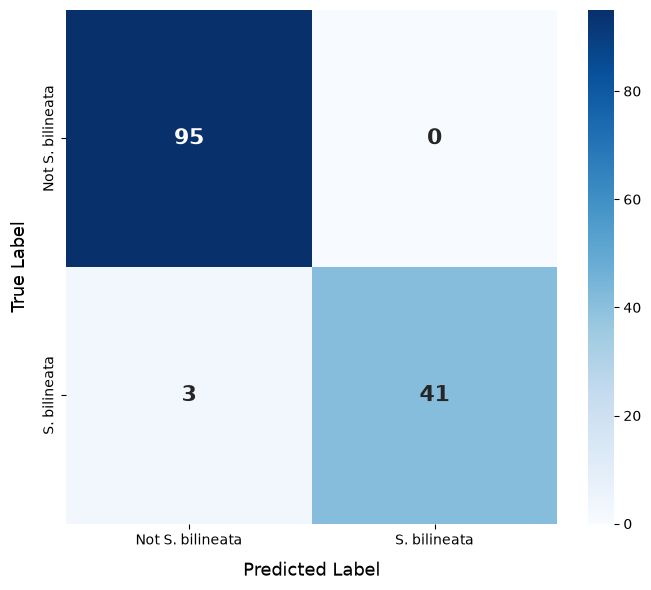

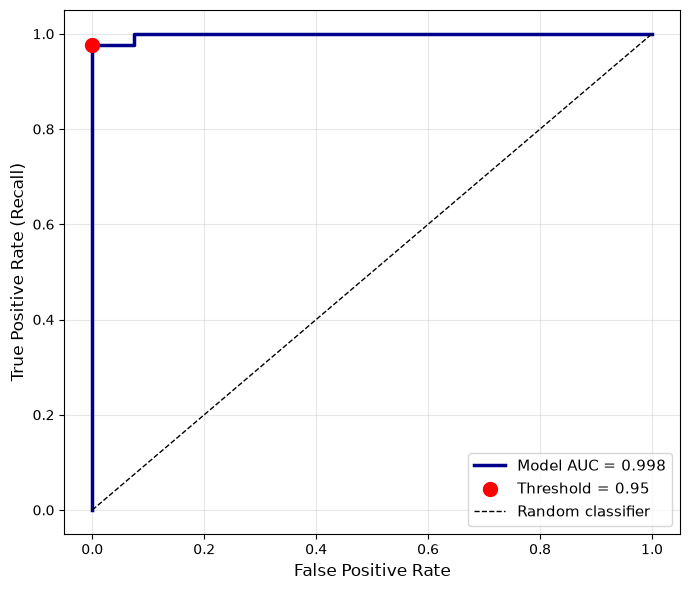

Saved: V6_Bruce_Wayne_roc_curve_THESIS.png


In [ ]:
# 8. Confusion Matrix Visualization
#%pip install seaborn
OUTPUT_DIR = '/Users/isabellesecord/Library/CloudStorage/OneDrive-ImperialCollegeLondon/AA - MRES PROJECT/Model Training Version 6/Model_V6_Outputs/'
checkpoint_path = os.path.join(OUTPUT_DIR, "Model_checkpoint.keras")


#load model
model = load_model(checkpoint_path,
    custom_objects={'loss_fn': loss_fn},
    compile=False
)
print("Model loaded")

#generate predictions
OPTIMAL_THRESHOLD = 0.95 # change this!!!

y_prob = model.predict(X_test).ravel()
y_pred = (y_prob >= OPTIMAL_THRESHOLD).astype(int)

#call confusion matrix
cm             = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print(f"  TP: {tp}  TN: {tn}  FP: {fp}  FN: {fn}")

fig, ax = plt.subplots(figsize=(7, 6))        # ← this line was missing
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Not S. bilineata', 'S. bilineata'],
    yticklabels=['Not S. bilineata', 'S. bilineata'],
    ax=ax,
    annot_kws={'size': 16, 'weight': 'bold'}
)

ax.set_xlabel('Predicted Label', fontsize=13, labelpad=10)
ax.set_ylabel('True Label', fontsize=13, labelpad=10)
#ax.set_title('Confusion Matrix\n'f'Saccopteryx bilineata Detector (threshold={OPTIMAL_THRESHOLD})', fontsize=12, fontweight='bold', pad=15)

plt.tight_layout()
#plt.savefig('Model_confusion_matrix_THESIS.png', dpi=300, bbox_inches='tight')
plt.show()

from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

fig, ax = plt.subplots(figsize=(7, 6))

# ROC curve
ax.plot(fpr, tpr, color='darkblue', linewidth=2.5,
        label=f'Model AUC = {auc_score:.3f}')

# Optimal threshold point
opt_idx  = np.argmin(np.abs(thresholds - OPTIMAL_THRESHOLD))
ax.scatter(fpr[opt_idx], tpr[opt_idx],
           color='red', s=100, zorder=5,
           label=f'Threshold = {OPTIMAL_THRESHOLD}')

# Random classifier line
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random classifier')

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=12)
#ax.set_title('ROC Curve — Model', fontsize=12, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
#plt.savefig('Model_roc_curve_THESIS.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: Model_roc_curve_THESIS.png")

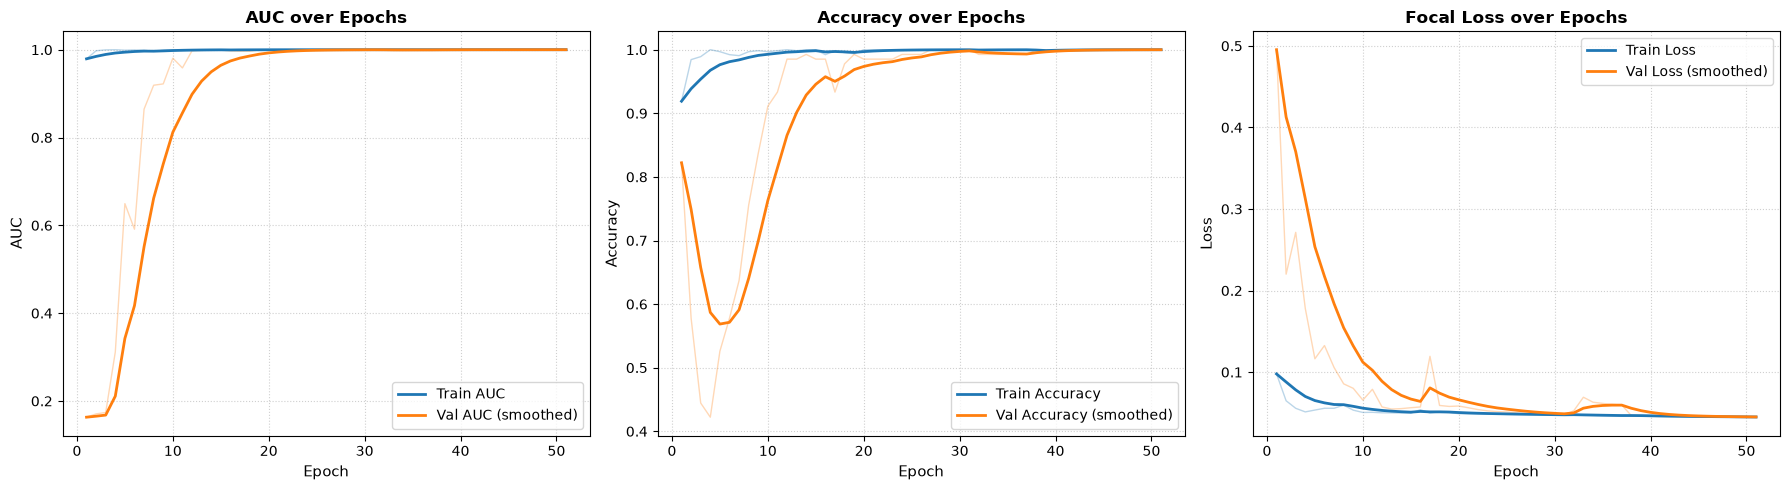

✨ Clean figure saved to: /Users/isabellesecord/Library/CloudStorage/OneDrive-ImperialCollegeLondon/AA - MRES PROJECT/Model Training Version 6/Model_V6_Outputs/V6_Bruce_Wayne_training_history_graphs.png


In [ ]:
#9. Learning Curve Plots
OUTPUT_DIR = '/Users/isabellesecord/Library/CloudStorage/OneDrive-ImperialCollegeLondon/AA - MRES PROJECT/Model Training Version 6/Model_V6_Outputs/'
log_csv_path = os.path.join(OUTPUT_DIR, 'Model_training_log.csv')

raw_df = pd.read_csv(log_csv_path)

# Find the start index of the latest training run (where epoch resets to 0)
if 'epoch' in raw_df.columns:
    reset_indices = raw_df[raw_df['epoch'] == 0].index
    if len(reset_indices) > 1:
        last_run_start = reset_indices[-1]
        history_df = raw_df.iloc[last_run_start:].copy().reset_index(drop=True)
        print(f"🧹 Cleaned log! Trimmed previous runs. Showing latest run ({len(history_df)} epochs).")
    else:
        history_df = raw_df.copy()
else:
    history_df = raw_df.copy()

# Save cleaned CSV back to disk
#history_df.to_csv(log_csv_path, index=False)

def smooth(values, weight=0.7):
    smoothed = []
    last = values[0]
    for val in values:
        smoothed_val = last * weight + (1 - weight) * val
        smoothed.append(smoothed_val)
        last = smoothed_val
    return smoothed

# Plot Clean Single Run
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
epochs = history_df['epoch'] + 1 if 'epoch' in history_df.columns else range(1, len(history_df) + 1)

# Panel 1: AUC
axes[0].plot(epochs, history_df['auc'], color='#1f77b4', alpha=0.3, linewidth=1)
axes[0].plot(epochs, history_df['val_auc'], color='#ff7f0e', alpha=0.3, linewidth=1)
axes[0].plot(epochs, smooth(history_df['auc']), color='#1f77b4', linewidth=2, label='Train AUC')
axes[0].plot(epochs, smooth(history_df['val_auc']), color='#ff7f0e', linewidth=2, label='Val AUC (smoothed)')
axes[0].set_title('AUC over Epochs', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=11)
axes[0].set_ylabel('AUC', fontsize=11)
axes[0].legend(loc='lower right', frameon=True)
axes[0].grid(True, linestyle=':', alpha=0.6)

# Panel 2: Accuracy
axes[1].plot(epochs, history_df['accuracy'], color='#1f77b4', alpha=0.3, linewidth=1)
axes[1].plot(epochs, history_df['val_accuracy'], color='#ff7f0e', alpha=0.3, linewidth=1)
axes[1].plot(epochs, smooth(history_df['accuracy']), color='#1f77b4', linewidth=2, label='Train Accuracy')
axes[1].plot(epochs, smooth(history_df['val_accuracy']), color='#ff7f0e', linewidth=2, label='Val Accuracy (smoothed)')
axes[1].set_title('Accuracy over Epochs', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=11)
axes[1].set_ylabel('Accuracy', fontsize=11)
axes[1].legend(loc='lower right', frameon=True)
axes[1].grid(True, linestyle=':', alpha=0.6)

# Panel 3: Loss
axes[2].plot(epochs, history_df['loss'], color='#1f77b4', alpha=0.3, linewidth=1)
axes[2].plot(epochs, history_df['val_loss'], color='#ff7f0e', alpha=0.3, linewidth=1)
axes[2].plot(epochs, smooth(history_df['loss']), color='#1f77b4', linewidth=2, label='Train Loss')
axes[2].plot(epochs, smooth(history_df['val_loss']), color='#ff7f0e', linewidth=2, label='Val Loss (smoothed)')
axes[2].set_title('Focal Loss over Epochs', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Epoch', fontsize=11)
axes[2].set_ylabel('Loss', fontsize=11)
axes[2].legend(loc='upper right', frameon=True)
axes[2].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
save_path = os.path.join(OUTPUT_DIR, 'Model_training_history_graphs.png')
#plt.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"✨ Clean figure saved to: {save_path}")

🔄 Loading Best Model Checkpoint from: V6_Bruce_Wayne_checkpoint.keras

📊 Generating 2D Architecture Flowchart...


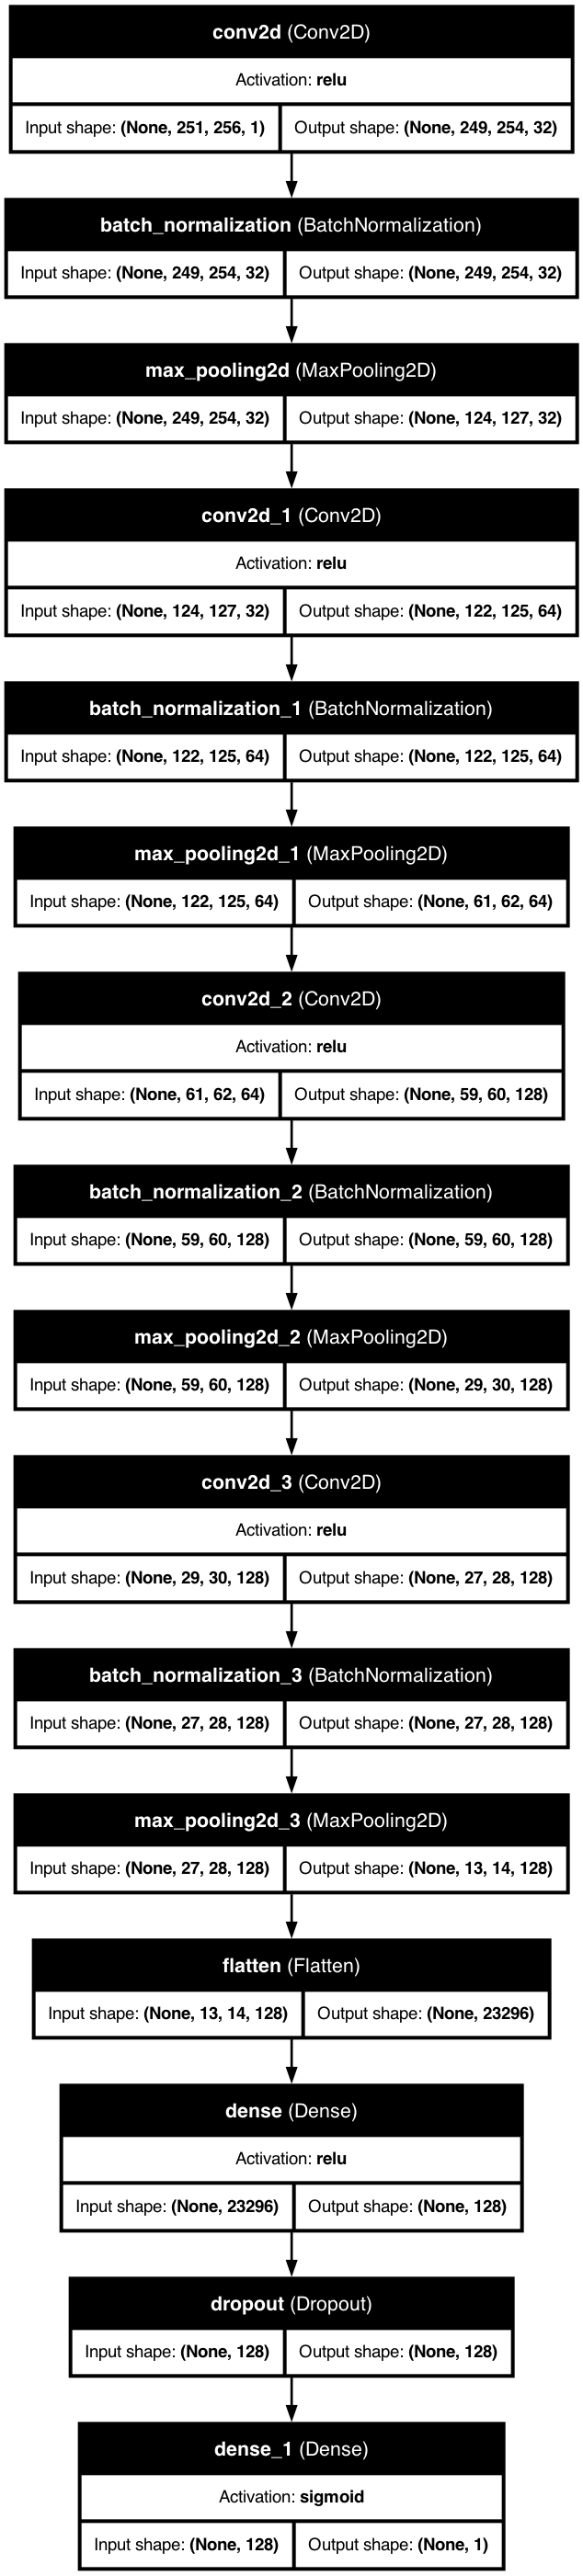


🧱 Generating 3D Architecture Map...


/Users/isabellesecord/Library/CloudStorage/OneDrive-ImperialCollegeLondon/AA - MRES PROJECT/Model Training version 1/bat_env/lib/python3.11/site-packages/visualkeras/layered.py:231: UserWarning: The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.
  warnings.warn("The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.")


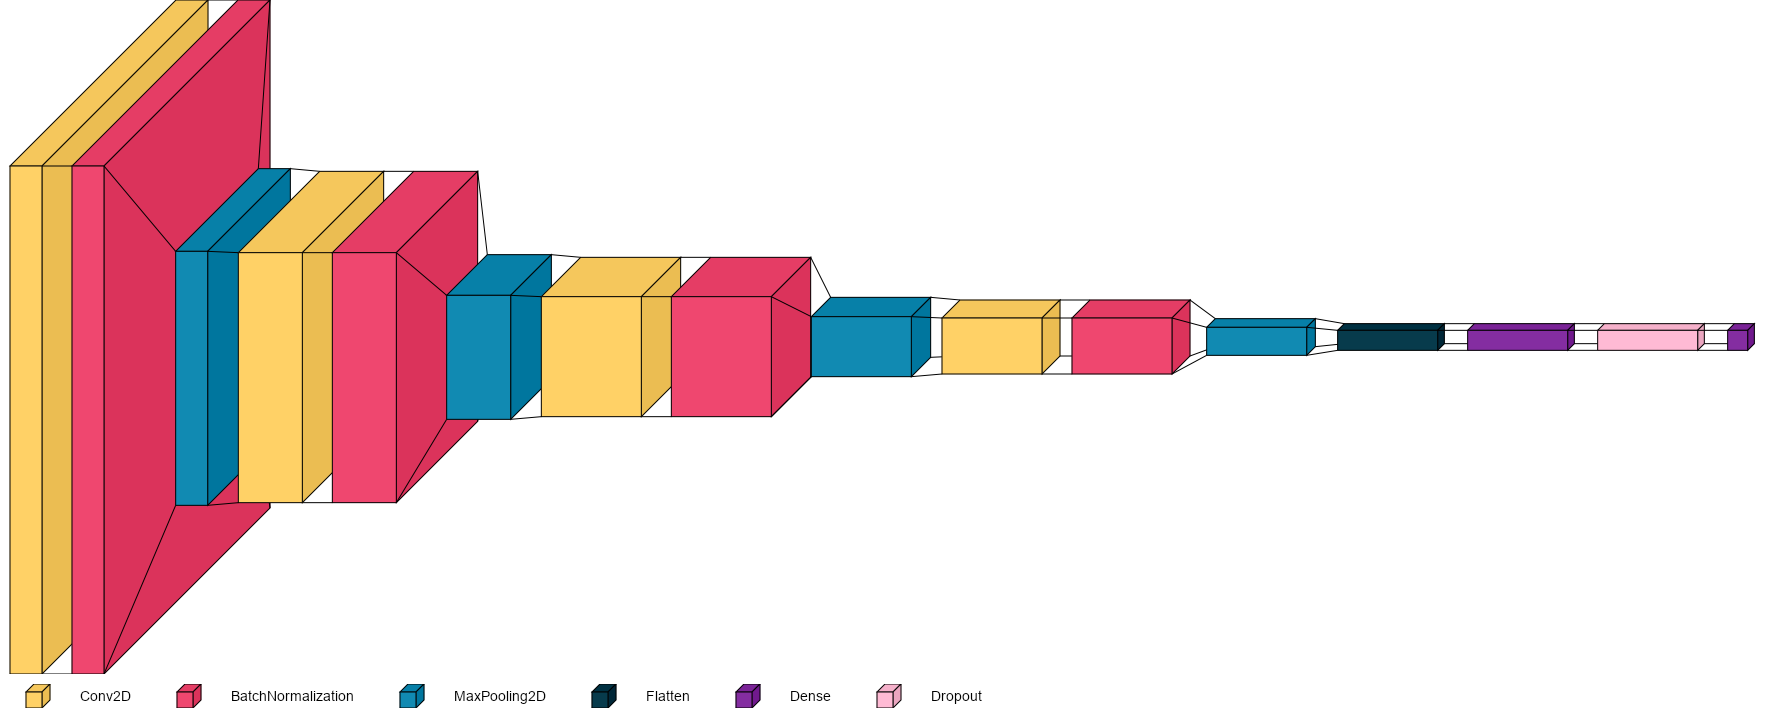

In [ ]:
# 10. MODEL ARCHITECTURE VISUALIZATION
import os
import sys
import tensorflow as tf
from IPython.display import display, Image as IPyImage
import visualkeras
from PIL import ImageFont

# ---------------------------------------------------------
# 1. PATH FIX & DIRECTORY SETUP
# ---------------------------------------------------------
os.environ["PATH"] += os.pathsep + "/opt/homebrew/bin" + os.pathsep + "/usr/local/bin"

OUTPUT_DIR = "/Users/isabellesecord/Library/CloudStorage/OneDrive-ImperialCollegeLondon/AA - MRES PROJECT/Model Training Version 6/Model_V6_Outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

checkpoint_path = os.path.join(OUTPUT_DIR, "Model_checkpoint.keras")

print(f"🔄 Loading Best Model Checkpoint from: {os.path.basename(checkpoint_path)}")
best_model = tf.keras.models.load_model(
    checkpoint_path, 
    custom_objects={'loss_fn': loss_fn}, 
    compile=False
)

# ---------------------------------------------------------
# 2. KERAS PLOT MODEL (2D Flowchart)
# ---------------------------------------------------------
print("\n📊 Generating 2D Architecture Flowchart...")
plot_path = os.path.join(OUTPUT_DIR, "Model_Flowchart.png")

try:
    tf.keras.utils.plot_model(
        best_model,
        to_file=plot_path,
        show_shapes=True,
        show_layer_names=True,
        show_layer_activations=True,
        dpi=200,
        rankdir='TB',
    )
    
    if os.path.exists(plot_path):
        display(IPyImage(filename=plot_path))
    else:
        print("⚠️ Flowchart missing. Run 'pip install pydot' in your bat_env and restart Jupyter.")

except Exception as e:
    print(f"⚠️ Could not generate 2D Flowchart: {e}")

# ---------------------------------------------------------
# 3. VISUALKERAS (3D Block Map)
# ---------------------------------------------------------
print("\n🧱 Generating 3D Architecture Map...")

# --- KERAS 3 BUG PATCH FOR VISUALKERAS ---
# This safely gives VisualKeras the output_shape attribute it is looking for
for layer in best_model.layers:
    if not hasattr(layer, 'output_shape'):
        try:
            layer.output_shape = layer.output.shape
        except AttributeError:
            pass
# -----------------------------------------

try:
    font = ImageFont.truetype("Arial.ttf", 14)
except IOError:
    font = ImageFont.load_default()

vk_plot = visualkeras.layered_view(
    best_model, 
    legend=True, 
    font=font,
    spacing=30,      
    scale_xy=2,      
    scale_z=1,       
    max_z=100,
)

vk_plot_path = os.path.join(OUTPUT_DIR, "Model_3D_Map.png")
vk_plot.save(vk_plot_path)

# Display 3D map inline in Jupyter
display(vk_plot)